# Concrete Strength – Data Preprocessing (Team 6)

**DATA 4950 – Spring 2026 – Data Science Capstone**

**Date:** 03/22/2026

1. Load Data
2. Drop Rows with Missing Target
3. Simple Cleaning 
4. Train–Test Split
5. Handle Missing Values
6. Handle Outliers

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

print("✓ Libraries loaded!")

✓ Libraries loaded!


## 1. Load Data

**Observations**

- The raw dataset has 1,030 rows and 9 columns, as shown by `shape = (1030, 9)`.  
- All 9 columns are numeric: 8 `float64` features for the concrete mix components and 1 `int64` feature for `Age (day)`.  
- The target variable is `Concrete compressive strength(MPa, megapascals)`, which is stored as a float and has 1,030 non‑null values.  
- From Notebook 01 (EDA), we plan to address right‑skewed ingredient distributions, high‑end outliers (e.g., very high strength or long curing ages), and large differences in feature scales across the ingredients.


In [118]:
df = pd.read_csv(
    r"C:\Users\otfxa\Documents\GitHub\Team6-R3ConcreteStrengthPrediction\data\raw\Concrete_Data.csv"
)

df.columns = df.columns.str.strip()
print(df.head())
print(df.shape)
print(df.info())

   Cement (component 1)(kg in a m^3 mixture)  \
0                                      540.0   
1                                      540.0   
2                                      332.5   
3                                      332.5   
4                                      198.6   

   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
0                                                0.0       
1                                                0.0       
2                                              142.5       
3                                              142.5       
4                                              132.4       

   Fly Ash (component 3)(kg in a m^3 mixture)  \
0                                         0.0   
1                                         0.0   
2                                         0.0   
3                                         0.0   
4                                         0.0   

   Water  (component 4)(kg in a m^3 mixture)  \
0      

## 2. Drop Rows with Missing TARGET

**Observations**

- Number of rows with missing target: 0.  
- This represents 0.00% of the dataset (0 out of 1,030 rows).  
- After dropping rows with missing target, 1,030 rows remain, so no data was lost in this step.


In [121]:
target_col = 'Concrete compressive strength(MPa, megapascals)'

missing_target = df[target_col].isnull().sum()
total_rows = len(df)
pct_missing_target = missing_target / total_rows * 100

print(f"Missing target rows: {missing_target}")
print(f"Percent missing target: {pct_missing_target:.2f}%")

df = df.dropna(subset=[target_col])
print(f"Rows remaining after dropping missing target: {len(df)}")

Missing target rows: 0
Percent missing target: 0.00%
Rows remaining after dropping missing target: 1030


## 3. Simple Cleaning (Before Split)

These operations are safe before splitting because they do not use statistics.

**Observations**

- We found 0 duplicate rows, so no rows were removed for duplication and `df_clean` still has 1,030 rows.  
- There are no obvious data‑leakage columns in this dataset; all ingredient quantities and `Age (day)` are known before compressive strength is measured.  
- The summary statistics show positive, realistic ranges for all features (for example, `Age (day)` runs from 1 to 365 days and all mix components are non‑negative), so we did not drop any rows for impossible values.


In [124]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    df_clean = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")
else:
    df_clean = df.copy()
    print("No duplicate rows removed")

print(df_clean.describe())

Duplicate rows found: 25
Removed 25 duplicate rows
       Cement (component 1)(kg in a m^3 mixture)  \
count                                1005.000000   
mean                                  278.631343   
std                                   104.344261   
min                                   102.000000   
25%                                   190.700000   
50%                                   265.000000   
75%                                   349.000000   
max                                   540.000000   

       Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
count                                        1005.000000       
mean                                           72.043483       
std                                            86.170807       
min                                             0.000000       
25%                                             0.000000       
50%                                            20.000000       
75%                             

## 4. Train–Test Split

**Observations**

- We split the data using an 80/20 split with `test_size = 0.2` and `random_state = 4950`.  
- This produced 824 rows in the training set and 206 rows in the test set, with 8 predictor columns in each set and 1 target column.  
- Because this is a regression problem, we used a standard split without stratification; the target’s range and typical values look similar between train and test based on the earlier EDA.


In [127]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=4950
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (804, 8)
X_test shape: (201, 8)
y_train shape: (804,)
y_test shape: (201,)


## 5. Handle Missing Values

**Strategy (Column / % Missing / Strategy / Reasoning)**

All feature columns (8 mix components + `Age (day)`) have 0.0% missing in the training data, so we keep them as‑is with no imputation.

**Observations**

`X_train`, `X_test`, `y_train`, and `y_test` all have 0 missing values, so no mean, median, mode, or row‑dropping steps were required.


In [130]:
print("Total missing in X_train:", X_train.isnull().sum().sum())
print("Total missing in X_test:", X_test.isnull().sum().sum())
print("Total missing in y_train:", y_train.isnull().sum())
print("Total missing in y_test:", y_test.isnull().sum())

Total missing in X_train: 0
Total missing in X_test: 0
Total missing in y_train: 0
Total missing in y_test: 0


In [132]:
numeric_cols = X_train.columns

outlier_info = []
for col in numeric_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    pct_outliers = n_outliers / len(X_train) * 100

    outlier_info.append({
        "Column": col,
        "% Outliers": pct_outliers,
        "Lower": lower,
        "Upper": upper
    })

outlier_df = pd.DataFrame(outlier_info)
outlier_df

,Column,% Outliers,Lower,Upper
0,Cement (component 1)(kg in a m^3 mixture),0.000000,-47.7500,587.0500
1,Blast Furnace Slag (component 2)(kg in a m^3 m...,0.124378,-213.8625,356.4375
2,Fly Ash (component 3)(kg in a m^3 mixture),0.000000,-177.4500,295.7500
3,Water (component 4)(kg in a m^3 mixture),1.741294,128.3750,231.3750
4,Superplasticizer (component 5)(kg in a m^3 mix...,1.119403,-15.0375,25.0625
5,Coarse Aggregate (component 6)(kg in a m^3 mi...,0.000000,787.4000,1173.0000
6,Fine Aggregate (component 7)(kg in a m^3 mixture),0.621891,582.2500,970.6500
7,Age (day),6.094527,-49.0000,119.0000


In [134]:
X_train_capped = X_train.copy()
X_test_capped = X_test.copy()

for col in numeric_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_train_capped[col] = X_train_capped[col].clip(lower, upper)
    X_test_capped[col] = X_test_capped[col].clip(lower, upper)

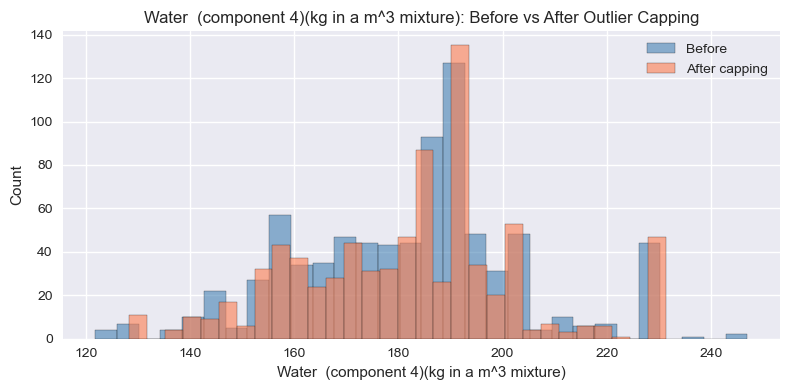

In [136]:
col = 'Water  (component 4)(kg in a m^3 mixture)'

plt.figure(figsize=(8, 4))
plt.hist(X_train[col], bins=30, alpha=0.6, label='Before', color='steelblue', edgecolor='black')
plt.hist(X_train_capped[col], bins=30, alpha=0.6, label='After capping', color='coral', edgecolor='black')
plt.xlabel(col)
plt.ylabel('Count')
plt.title(f'{col}: Before vs After Outlier Capping')
plt.legend()
plt.tight_layout()
plt.show()

In [138]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X_train_final = X_train_capped.copy()
X_test_final = X_test_capped.copy()

baseline_model = LinearRegression()
baseline_model.fit(X_train_final, y_train)

y_train_pred = baseline_model.predict(X_train_final)
y_test_pred = baseline_model.predict(X_test_final)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print('Baseline Model Performance')
print('=' * 50)
print(f'{"Metric":<10} {"Train":>12} {"Test":>12}')
print('-' * 50)
print(f'{"R²":<10} {train_r2:>12.4f} {test_r2:>12.4f}')
print(f'{"RMSE":<10} {train_rmse:>12.4f} {test_rmse:>12.4f}')

Baseline Model Performance
Metric            Train         Test
--------------------------------------------------
R²               0.7416       0.6679
RMSE             8.3451       9.0518


## 6. Handle Outliers

We used the IQR method on the **training data only** to flag outliers in each numeric column, then applied the same lower and upper bounds to both the training and test sets by capping values outside those ranges.

**Outlier decisions (Column / % Outliers / Decision / Reasoning)**

- Cement (component 1)(kg in a m^3 mixture) / 0.00% / Keep / No training points fell outside the IQR bounds, so no capping was needed.  
- Blast Furnace Slag (component 2)(kg in a m^3 mixture) / 0.12% / Cap / A very small number of extreme slag values were capped to reduce their influence while keeping all mixes.  
- Fly Ash (component 3)(kg in a m^3 mixture) / 0.00% / Keep / No fly‑ash values were flagged as outliers under the IQR rule.  
- Water  (component 4)(kg in a m^3 mixture) / 1.74% / Cap / A few very low or high water contents were capped using the training IQR bounds to stabilize the model.  
- Superplasticizer (component 5)(kg in a m^3 mixture) / 1.12% / Cap / Rare high‑dose admixture values were capped so they do not dominate the regression fit.  
- Coarse Aggregate  (component 6)(kg in a m^3 mixture) / 0.00% / Keep / Coarse aggregate values all fell within IQR limits, so no changes were needed.  
- Fine Aggregate (component 7)(kg in a m^3 mixture) / 0.62% / Cap / A small number of extreme fine‑aggregate values were capped to keep them in a reasonable range.  
- Age (day) / 6.09% / Cap / Several very long curing ages (up to 365 days) were capped at the IQR‑based upper bound to reduce their leverage without discarding any rows.
